In [8]:
from ib_insync import *

util.startLoop()

ib = IB()
ib.connect('127.0.0.1', 7497, clientId=30)

contract = Stock('PLTR', 'SMART', 'USD')

bars = ib.reqHistoricalData(
    contract=contract,
    endDateTime='',
    durationStr='5 Y',
    barSizeSetting='1 day',
    whatToShow='TRADES',
    useRTH=False,
    formatDate=1
)

PLTR_data = util.df(bars)
PLTR_data.to_csv("PLTR_HistoricalData.csv", index=False)

ib.disconnect()

In [1]:
import pandas as pd
PLTR_data = pd.read_csv("PLTR_HistoricalData.csv", )

In [2]:
PLTR_data.head(10)

,date,open,high,low,close,volume,average,barCount
0,2021-01-05,23.55,24.6700,22.89,24.46,26983758.0,23.95497,70784
1,2021-01-06,24.15,24.6000,23.25,23.75,29561277.0,23.87201,79922
2,2021-01-07,23.79,25.1900,23.67,25.13,30279558.0,24.56161,74524
3,2021-01-08,25.50,26.4400,24.70,25.19,37913285.0,25.60079,95881
4,2021-01-11,25.40,26.6000,24.23,26.08,30210738.0,25.79968,76498
5,2021-01-12,26.17,26.5000,25.51,26.34,25108398.0,26.00649,57636
6,2021-01-13,26.26,27.4298,25.06,25.42,47799640.0,26.16658,133283
7,2021-01-14,25.50,26.6400,24.37,26.56,30202393.0,25.04724,87695
8,2021-01-15,26.50,28.0000,25.46,25.75,87147333.0,26.75847,234947
9,2021-01-19,26.50,27.5400,25.88,26.79,44105126.0,26.76067,117247


In [3]:
PLTR_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      1255 non-null   object 
 1   open      1255 non-null   float64
 2   high      1255 non-null   float64
 3   low       1255 non-null   float64
 4   close     1255 non-null   float64
 5   volume    1255 non-null   float64
 6   average   1255 non-null   float64
 7   barCount  1255 non-null   int64  
dtypes: float64(6), int64(1), object(1)
memory usage: 78.6+ KB


In [4]:
PLTR_data.describe()

,open,high,low,close,volume,average,barCount
count,1255.000000,1255.000000,1255.000000,1255.000000,1.255000e+03,1255.000000,1255.000000
mean,43.757211,45.018417,42.476759,43.796671,5.355283e+07,43.773677,145215.620717
std,51.631873,52.887331,50.285898,51.655538,3.580618e+07,51.632898,108007.489225
min,5.920000,6.170000,5.920000,5.920000,8.364040e+06,6.039310,17378.000000
25%,12.995000,13.595000,12.640000,13.025000,3.154532e+07,13.038145,71954.000000
50%,22.510000,22.900000,21.750000,22.370000,4.343076e+07,22.400460,113021.000000
75%,37.800000,39.865000,36.595000,38.035000,6.226882e+07,38.149380,183334.500000
max,203.100000,222.000000,198.320000,201.560000,3.992103e+08,205.819000,852827.000000


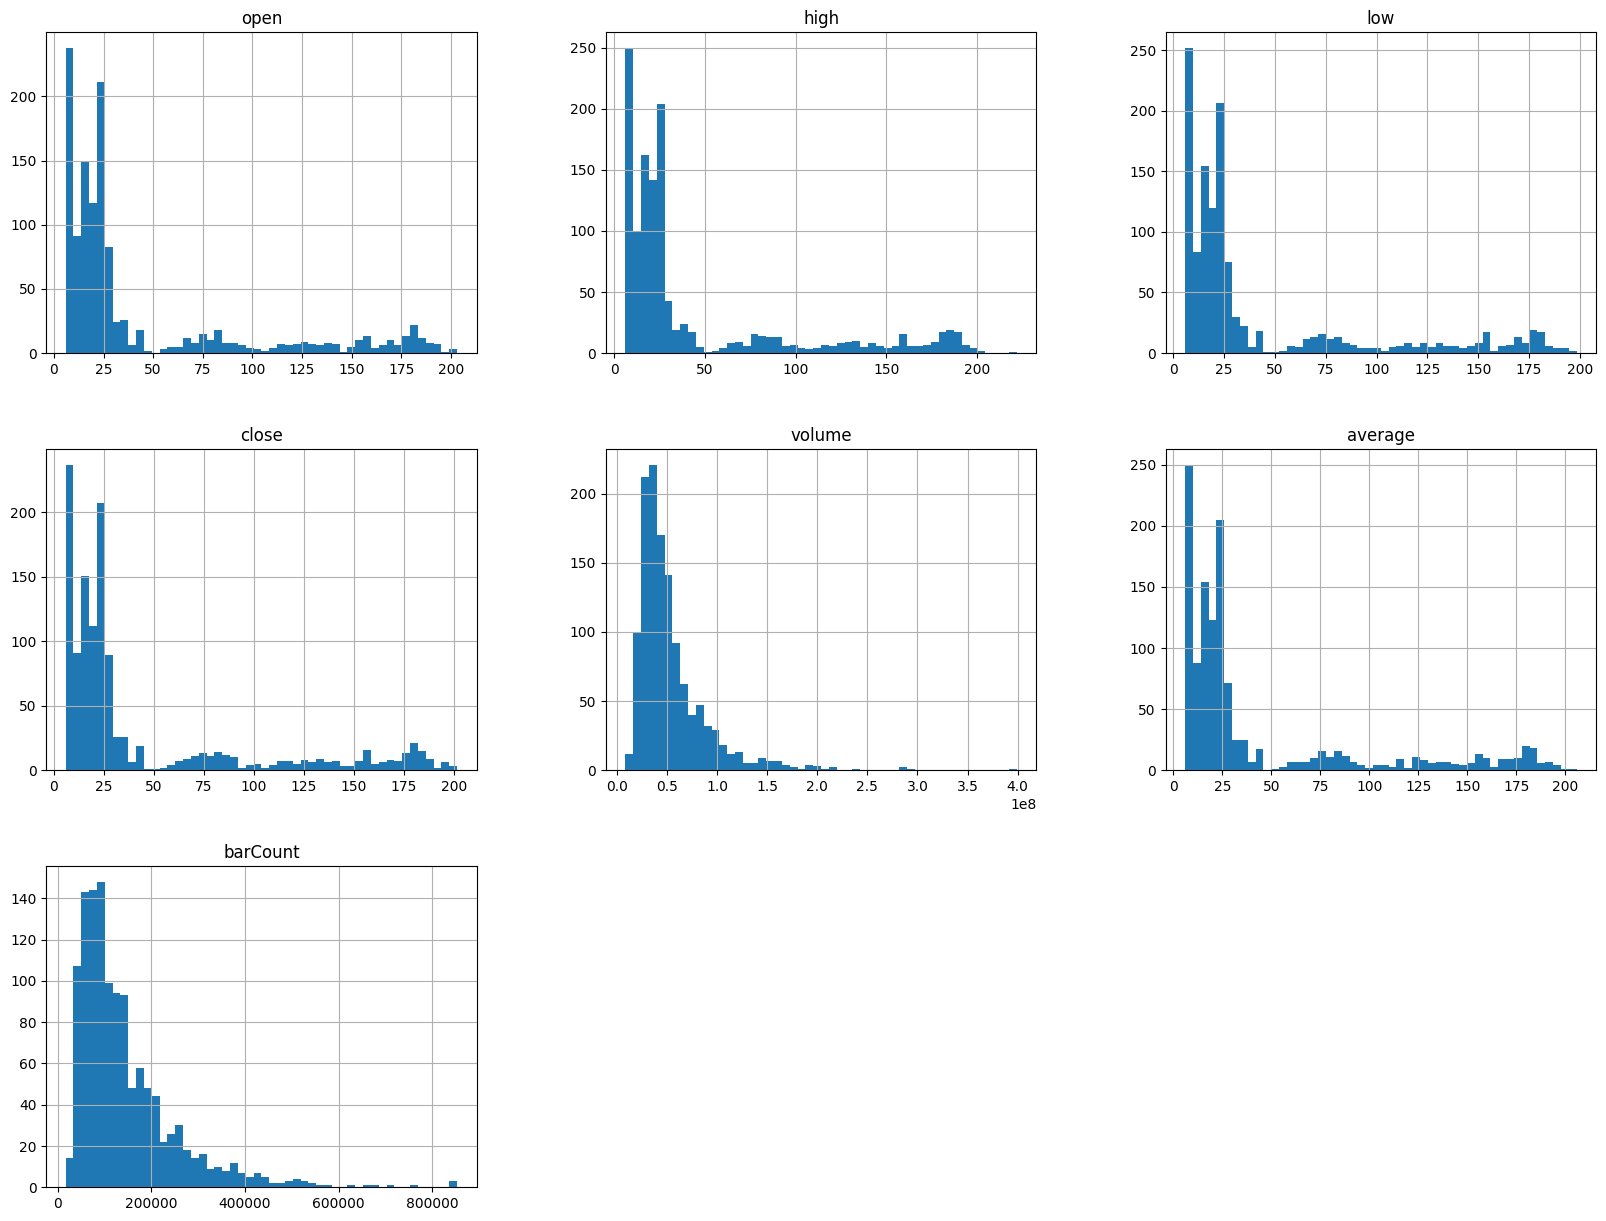

In [5]:
import matplotlib.pyplot as plt
PLTR_data.hist(bins=50, figsize=(20,15))
plt.show()

In [6]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
train_set, test_set = train_test_split(PLTR_data, test_size=0.2, random_state=42)

In [7]:
corr_matrix = PLTR_data.corr(numeric_only=True)


In [8]:
corr_matrix["close"].sort_values(ascending=False)

close       1.000000
average     0.999702
low         0.999437
high        0.999356
open        0.998797
barCount    0.371333
volume      0.094636
Name: close, dtype: float64

The list of numerical attributes from correlation function show all the attributes have strong positive correlations to stock close price.

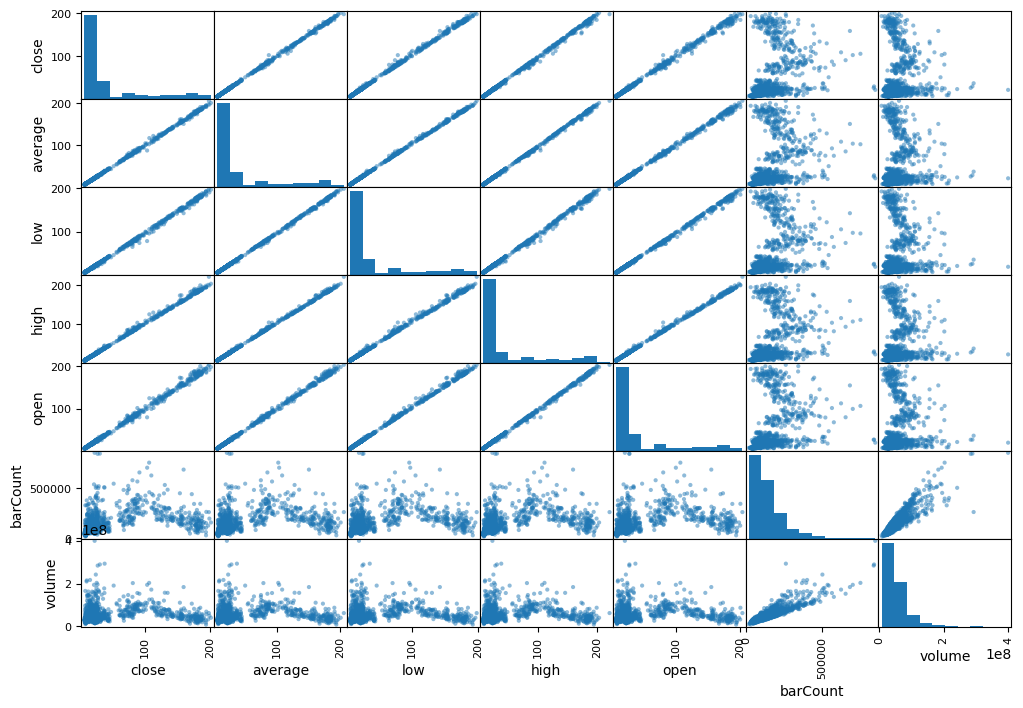

In [9]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
attributes = ["close", "average", "low", "high", "open", "barCount", "volume"]
scatter_matrix(PLTR_data[attributes], figsize=(12, 8))
plt.show()

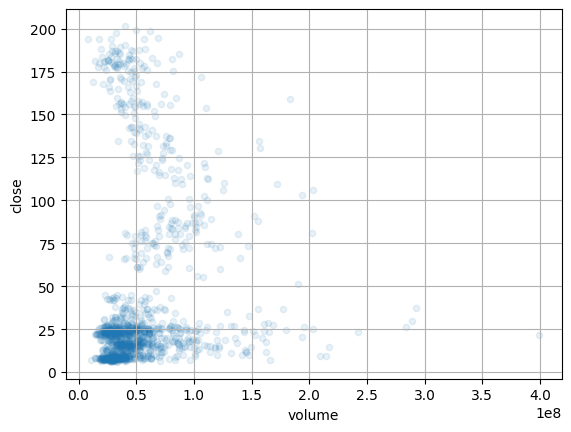

In [10]:
PLTR_data.plot(kind="scatter", x="volume", y="close", alpha=0.1, grid=True)
plt.show()

In [11]:
# remove date column for ML algoritthms
PLTR_data = PLTR_data.copy() # create a copy to avoid changing original data
PLTR_data.drop("date", axis=1, inplace=True)


In [12]:
# check that date columns is removed 
PLTR_data.head()

,open,high,low,close,volume,average,barCount
0,23.55,24.67,22.89,24.46,26983758.0,23.95497,70784
1,24.15,24.60,23.25,23.75,29561277.0,23.87201,79922
2,23.79,25.19,23.67,25.13,30279558.0,24.56161,74524
3,25.50,26.44,24.70,25.19,37913285.0,25.60079,95881
4,25.40,26.60,24.23,26.08,30210738.0,25.79968,76498


In [13]:
PLTR_data_num = PLTR_data[["open", "high", "low", "close", "volume", "average", "barCount"]]

In [14]:
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()
PLTR_data_scaled = std_scaler.fit_transform(PLTR_data_num)


In [15]:
from sklearn.metrics.pairwise import rbf_kernel
PLTR_data_kernel = rbf_kernel(PLTR_data[["close"]], [[35]], gamma=0.1)


In [16]:
PLTR_data_kernel

array([[1.49745270e-05],
       [3.18757538e-06],
       [5.87811108e-05],
       ...,
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00]])

In [17]:
PLTR_data_targets = PLTR_data["close"]

In [18]:
from sklearn.ensemble import GradientBoostingRegressor
gbrt = GradientBoostingRegressor(max_depth=5, n_estimators=100,  learning_rate=0.2, random_state=42)
gbrt.fit(PLTR_data_num, PLTR_data_targets)

,loss,'squared_error'
,learning_rate,0.2
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [19]:
gbrt.n_estimators_

100

In [20]:
gbrt.score(PLTR_data_num, PLTR_data_targets)

0.9999994227813038

In [21]:
gbrt_predictions = gbrt.predict(PLTR_data_num)
gbrt_predictions

array([ 24.44375129,  23.78167583,  25.14885857, ..., 180.11961078,
       177.72907708, 169.60589335])

In [22]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(PLTR_data_targets, gbrt_predictions)

In [23]:
print("RSME:",  rmse)

RSME: 0.03922960956115224


In [24]:
#  save the model 
import joblib
joblib.dump(gbrt, "PLTR_GBRT_model.pkl")

['PLTR_GBRT_model.pkl']